In [ ]:
import sys
from pathlib import Path
# Add project root to sys.path so 'src.*' imports resolve correctly
sys.path.insert(0, str(Path("../..").resolve()))

# Notebook Overview

**Purpose:**
This notebook evaluates Optuna-selected LSTM and xLSTM models for AAPL on the test set and translates multi-horizon price forecasts into a simple rule-based trading strategy. For each model type, feature set, and forecast horizon, it loads the best trial from the corresponding Optuna study, generates denormalised test predictions, computes standard forecasting metrics, and simulates a Long/Flat portfolio driven by forecast-derived expected return and downside risk signals. Results are compared against a Buy-and-Hold benchmark.

**Inputs:**
- AAPL sentiment-augmented time series CSV: `../data/ts_with_sentiment/AAPL_ts_with_sentiment.csv`
- Optuna studies (SQLite): `../data/optuna_studies/BachelorThesis.db`
- Model checkpoints:
  - Preferred: locally copied “best models” in `data/best_models/AAPL/`
  - Fallback: original Optuna checkpoint paths stored in each trial (`best_checkpoint_path`)
- Evaluation settings defined in the configuration block:
  - Feature sets (`price_only`, `price_plus_sentiment`)
  - Horizons (`HORIZONS`), window size (`WINDOW_SIZE`), stride (`STRIDE`)
  - Normalisation (`NORMALISE`, `NORM_METHOD`)
  - Strategy parameters (initial capital, buy/sell thresholds, downside constraint)

**Outputs:**
- Console logs per configuration including:
  - Test-set RMSE and R² on the denormalised price level
  - Final portfolio value and Buy-and-Hold value
- Per-configuration plots showing portfolio equity curves versus Buy-and-Hold on the test period.
- A consolidated results table (`df_results` / `df_display`) containing forecasting metrics and portfolio outcomes, including excess return percentage relative to the benchmark.

**Process Summary:**
For each combination of model type, feature set, and horizon, the notebook loads the associated Optuna study and selects a Pareto-optimal trial using a deterministic rule (minimum RMSE, then maximum R²). It reconstructs the test set using the same preprocessing pipeline as training, restores the selected checkpoint, and produces multi-horizon forecasts. Predictions and targets are denormalised to the original price scale to compute test RMSE and R².
To link forecasts to trading decisions, the notebook computes a weighted expected return signal across the horizon and a downside-risk proxy (minimum predicted return). A Long/Flat strategy is then simulated: it fully allocates to the stock when expected return exceeds a buy threshold while downside remains acceptable, and otherwise stays in cash when sell or risk conditions are triggered. Performance is reported and compared to a Buy-and-Hold baseline over the same test dates.


In [4]:
# =========================
# Imports
# =========================
from pathlib import Path
from typing import Dict, Any, List, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import optuna
from sklearn.metrics import r2_score, root_mean_squared_error

import torch

from src.model_wrapper import Model, set_global_seed
from src.data_prep import PrepAndDataLoader

# Optuna Logging reduzieren
optuna.logging.set_verbosity(optuna.logging.WARNING)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Info] Using device: {DEVICE}")

[Info] Using device: cpu


In [5]:
# %%
# =========================
# Plot style (HHN thesis style)
# =========================
def set_hhn_plot_style() -> None:
    plt.style.use("default")
    mpl.rcParams.update({
        # Fonts & text
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,

        # Lines
        "lines.linewidth": 1.4,
        "lines.markersize": 4,

        # Colors
        "axes.prop_cycle": mpl.cycler(color=[
            "#003366",  # HHN blue
            "#999999",  # neutral gray
            "#0072B2",  # lighter blue
            "#CC0000",  # red accent
            "#56B4E9",  # light blue
        ]),

        # Axes & grid
        "axes.edgecolor": "#333333",
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.color": "#cccccc",
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,

        # Background
        "figure.facecolor": "white",
        "axes.facecolor": "white",

        # Legend
        "legend.frameon": False,
        "legend.loc": "best",

        # Savefig
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })


set_hhn_plot_style()


In [6]:
# =========================
# Global configuration
# =========================

# --- Daten & Ticker ---
TICKER: str = "AAPL"
DATA_FILE: str = f"../../data/ts_with_sentiment/{TICKER}_ts_with_sentiment.csv"
TARGET_COL: str = "Close"

TRAIN_SPLIT: float = 0.6
VAL_SPLIT: float = 0.2

# Feature-Sets: 1 Feature vs. 5 Features
FEATURE_SETS: Dict[str, List[str]] = {
    "price_only": ["Close"],  # 1 Feature
    "price_plus_sentiment": [  # 5 Features
        "Close",
        "pos_mean",
        "neut_mean",
        "neg_mean",
        "news_count",
    ],
}

# --- Window / Horizon settings ---
WINDOW_SIZE: int = 60
HORIZONS: List[int] = [1, 3, 5, 10, 15]
STRIDE: int = 1

# --- Normalisierung (muss zum Training passen) ---
NORMALISE: bool = True
NORM_METHOD: Literal["percentage", "minmax"] = "percentage"

# --- Modell / Optuna settings ---
MODEL_TYPES: List[str] = ["xLSTM", "LSTM"]

DB_PATH = Path("../../data/optuna/studies/BachelorThesis.db")
DB_PATH.parent.mkdir(parents=True, exist_ok=True)
STORAGE_URL = f"sqlite:///{DB_PATH.as_posix()}"

CHECKPOINT_DIR_TEMPLATE: str = (
    "../../data/optuna/checkpoints/{model_type}_optuna_H{horizon}_F{n_features}"
)

# Directory mit kopierten BestModels
BESTMODELS_DIR = Path("../../data") / "best_models" / TICKER

# --- Trading-Strategie Parameter (Option A: Full Long/Flat) ---
INITIAL_CAPITAL: float = 10_000.0

BUY_THRESHOLD: float = 0.005  #  +0.5 % erwartete Rendite -> Long
SELL_THRESHOLD: float = -0.005  #  -0.5 % erwartete Rendite -> Flat
DD_MIN: float = -0.05  #  -5 % erwartete Downside innerhalb Fensters → Vorsicht

# --- Batchgröße für Predictions ---
BATCH_SIZE: int = 128

# --- Seed ---
GLOBAL_SEED: int = 42

asset_name = TICKER  # für Plots


# =========================
# Helper: besten Trial aus Optuna-Study wählen
# =========================

def select_best_trial(study: optuna.Study) -> optuna.trial.FrozenTrial:
    """
    Wählt einen 'besten' Trial aus einer (multi-objective) Optuna-Study.

    Kriterium (intern, auf Basis der Optuna-Objektivwerte):
      1) minimaler RMSE (values[0])
      2) bei Gleichstand maximaler R² (values[1])
    """
    if hasattr(study, "best_trials") and study.best_trials:
        pareto_trials = study.best_trials
    else:
        pareto_trials = [study.best_trial]

    best = min(pareto_trials, key=lambda t: (t.values[0], -t.values[1]))
    return best


# =========================
# Helper: Testdaten für gegebene Konfiguration vorbereiten
# =========================

def prepare_test_data_for_config(
        feature_cols: List[str],
        horizon: int,
) -> Dict[str, Any]:
    """
    Erzeugt für gegebene Feature-Spalten und Horizont die TEST-Daten
    im gleichen Format wie beim Training.

    Rückgabe:
        {
            "prep": PrepAndDataLoader,
            "X_te": np.ndarray [N_te, W, F],
            "y_te": np.ndarray [N_te, H, 1],
            "dates_te": np.ndarray [N_te, H],
            "baseT_te": np.ndarray [N_te, 1] oder None,
        }
    """
    set_global_seed(GLOBAL_SEED)

    prep = PrepAndDataLoader(
        filename=DATA_FILE,
        training_split=TRAIN_SPLIT,
        validation_split=VAL_SPLIT,
        cols=feature_cols,
        target_col=TARGET_COL,
    )

    tmp_model = Model()
    X_tr, y_tr, X_va, y_va, X_te, y_te = tmp_model.prepare_data_from_prep(
        prep,
        normalise=NORMALISE,
        window_size=WINDOW_SIZE,
        prediction_range=horizon,
        norm_method=NORM_METHOD,
        stride=STRIDE,
        verbose=0,
    )

    dates_te = prep.get_prediction_dates(
        "test",
        window_size=WINDOW_SIZE,
        prediction_range=horizon,
        stride=STRIDE,
    )  # [N_te, H]

    baseT_te = tmp_model._cache.get("baseT_te", None)

    # Sicherheitshalber nach Datum sortieren (nach erstem Horizont-Tag)
    order = np.argsort(dates_te[:, 0])
    X_te = X_te[order]
    y_te = y_te[order]
    dates_te = dates_te[order]
    if baseT_te is not None:
        baseT_te = baseT_te[order]

    return {
        "prep": prep,
        "X_te": X_te,
        "y_te": y_te,
        "dates_te": dates_te,
        "baseT_te": baseT_te,
    }


# =========================
# Helper: Denormalisation + Test-Metriken (RMSE, R²)
# =========================

def denormalise_test_and_metrics(
        prep: PrepAndDataLoader,
        y_test_scaled: np.ndarray,  # [N, H, 1]
        y_pred_scaled: np.ndarray,  # [N, H]
        baseT_te: np.ndarray | None,
) -> Dict[str, Any]:
    """
    Denormalisiert Vorhersagen und Targets (sofern NORMALISE=True)
    und berechnet RMSE/R² im Original-Level auf dem TEST-Set.
    """
    y_pred_scaled_3d = y_pred_scaled[..., None]  # [N, H, 1]
    y_true_scaled_3d = y_test_scaled  # [N, H, 1]

    if NORMALISE:
        if NORM_METHOD == "percentage":
            if baseT_te is None:
                raise ValueError(
                    "baseT_te ist None, wird aber für percentage-Normalisierung benötigt."
                )

            y_pred_level = prep.denormalise(
                y_pred_scaled_3d,
                method="percentage",
                base_values=baseT_te,
                normalise=True,
            ).squeeze(-1)  # [N, H]

            y_true_level = prep.denormalise(
                y_true_scaled_3d,
                method="percentage",
                base_values=baseT_te,
                normalise=True,
            ).squeeze(-1)

        elif NORM_METHOD == "minmax":
            y_pred_level = prep.denormalise(
                y_pred_scaled_3d,
                method="minmax",
                base_values=None,
                normalise=True,
            ).squeeze(-1)

            y_true_level = prep.denormalise(
                y_true_scaled_3d,
                method="minmax",
                base_values=None,
                normalise=True,
            ).squeeze(-1)
        else:
            raise ValueError(f"Unknown normalization method: {NORM_METHOD}")
    else:
        y_pred_level = y_pred_scaled
        y_true_level = y_test_scaled.squeeze(-1)

    # Flatten für Metriken
    y_true_flat = y_true_level.reshape(-1)
    y_pred_flat = y_pred_level.reshape(-1)

    test_rmse_level = float(root_mean_squared_error(y_true_flat, y_pred_flat))
    test_r2_level = float(r2_score(y_true_flat, y_pred_flat))

    return {
        "y_true_level": y_true_level,
        "y_pred_level": y_pred_level,
        "test_rmse_level": test_rmse_level,
        "test_r2_level": test_r2_level,
    }


# =========================
# Helper: Horizont-Gewichte w_k
# =========================

def compute_horizon_weights(horizon: int) -> np.ndarray:
    """
    Berechnet Gewichte für die Horizonte 1..H.
    Kurze Horizonte werden stärker gewichtet als lange.

    Rückgabe: np.ndarray [H], Summe = 1.0
    """
    H = horizon
    if H <= 0:
        raise ValueError("Horizon must be >= 1")

    if H == 1:
        return np.array([1.0], dtype=float)

    w = np.zeros(H, dtype=float)

    if H <= 5:
        # Einfach: Tag 1 bekommt 0.5, Rest teilt sich 0.5
        w[0] = 0.5
        w[1:] = 0.5 / (H - 1)
    else:
        # Vorschlag:
        # - w1 = 0.4
        # - Tage 2..5 teilen sich 0.4
        # - Rest (6..H) teilt sich 0.2
        w[0] = 0.4
        mid_len = min(4, H - 1)  # max 4 Tage für mittlere Zone
        w[1:1 + mid_len] = 0.4 / mid_len
        remaining = H - 1 - mid_len  # restliche Tage
        if remaining > 0:
            w[1 + mid_len:] = 0.2 / remaining

    # Numerische Sicherheit
    w /= w.sum()
    return w


# =========================
# Helper: ER_t (expected return) & DD_t (downside) berechnen
# =========================

def compute_er_and_dd(
        y_pred_level: np.ndarray,  # [N, H]
        y_true_level: np.ndarray,  # [N, H]
        horizon: int,
) -> Dict[str, np.ndarray]:
    """
    Berechnet für jeden Test-Zeitpunkt i:
      - ER[i]: gewichtete erwartete Rendite über den Horizont
      - DD[i]: minimal erwartete Rendite (Downside-Risiko)

    r_{i,k} = P_pred[i,k] / P_true[i,0] - 1  (k=0..H-1 => t+1..t+H)

    ER[i] = Sum_k w_k * r_{i,k}
    DD[i] = min_k r_{i,k}
    """
    H = horizon
    if y_pred_level.shape[1] != H or y_true_level.shape[1] != H:
        raise ValueError("Shapes of y_pred_level/y_true_level do not match horizon.")

    # Preis zum Entscheidungszeitpunkt: P_t ≈ tatsächlicher Preis am ersten Horizont-Tag
    base_price = y_true_level[:, 0]  # [N]

    # Renditen r_{i,k} relativ zum Basispreis
    # y_pred_level[:, k] entspricht t+1..t+H
    r = (y_pred_level / base_price[:, None]) - 1.0  # [N, H]

    w = compute_horizon_weights(H)  # [H]
    ER = np.sum(r * w[None, :], axis=1)  # [N]
    DD = np.min(r, axis=1)  # [N]

    return {
        "ER": ER,
        "DD": DD,
        "base_price": base_price,
    }


# =========================
# Helper: Portfolio-Simulation (Option A: Full Long/Flat)
# =========================

def simulate_portfolio_long_flat(
        dates: np.ndarray,  # [N] (z.B. dates_te[:, 0])
        prices: np.ndarray,  # [N] (tatsächlicher Preis am ersten Horizont)
        ER: np.ndarray,  # [N]
        DD: np.ndarray,  # [N]
        initial_capital: float,
        buy_threshold: float,
        sell_threshold: float,
        dd_min: float,
) -> Dict[str, Any]:
    """
    Simuliert eine Long/Flat-Strategie:

    - Start: cash = initial_capital, shares = 0
    - BUY:  wenn ER > buy_threshold und DD > dd_min  -> alles in Aktien
    - SELL: wenn ER < sell_threshold oder DD < dd_min -> alles in Cash
    - sonst: HOLD (keine Änderung)

    Zusätzlich wird eine Buy&Hold-Strategie mit initial_capital als Benchmark berechnet.
    """
    N = len(dates)
    if not (len(prices) == len(ER) == len(DD) == N):
        raise ValueError("dates, prices, ER, DD müssen gleiche Länge haben.")

    # Long/Flat-Portfolio
    cash = initial_capital
    shares = 0.0

    portfolio_values = []
    cash_history = []
    shares_history = []

    # Buy&Hold-Benchmark
    price0 = prices[0]
    bh_shares = initial_capital / price0
    bh_values = []

    for t in range(N):
        price_t = prices[t]
        er_t = ER[t]
        dd_t = DD[t]

        # Handelslogik
        if er_t > buy_threshold and dd_t > dd_min:
            # BUY: alles in die Aktie (wenn noch nicht investiert)
            if shares == 0.0 and cash > 0.0:
                shares = cash / price_t
                cash = 0.0
        elif er_t < sell_threshold or dd_t < dd_min:
            # SELL: alles verkaufen (wenn investiert)
            if shares > 0.0:
                cash += shares * price_t
                shares = 0.0

        portfolio_value = cash + shares * price_t
        portfolio_values.append(portfolio_value)
        cash_history.append(cash)
        shares_history.append(shares)

        bh_values.append(bh_shares * price_t)

    portfolio_values = np.array(portfolio_values)
    bh_values = np.array(bh_values)
    cash_history = np.array(cash_history)
    shares_history = np.array(shares_history)

    return {
        "dates": dates,
        "portfolio_values": portfolio_values,
        "bh_values": bh_values,
        "cash_history": cash_history,
        "shares_history": shares_history,
        "final_portfolio_value": float(portfolio_values[-1]),
        "final_bh_value": float(bh_values[-1]),
    }


# =========================
# Helper: Plot Portfolio vs. Buy&Hold
# =========================

def plot_portfolio_vs_bh(
        dates: np.ndarray,
        portfolio_values: np.ndarray,
        bh_values: np.ndarray,
        model_type: str,
        horizon: int,
        n_features: int,
        feature_set_name: str,
):
    """
    Plot der Portfolioentwicklung (Long/Flat-Strategie) vs. Buy&Hold.
    """
    plt.figure(figsize=(12, 5))

    plt.plot(dates, portfolio_values, label="Model-based Portfolio")
    plt.plot(dates, bh_values, label="Buy & Hold", linestyle="--")

    title_main = (
        f"{asset_name} – {model_type} | H={horizon} | F={n_features} "
        f"({feature_set_name}) – TEST, 10.000 $ Startkapital"
    )
    plt.title(title_main)
    plt.xlabel("Date (Test set)")
    plt.ylabel("Portfolio Value [USD]")
    plt.legend()
    plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()



[INFO] Processing Study: LSTM_H1_F1
[WARN] Local best model not found: data\best_models\AAPL\LSTM_H1_F1_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\LSTM_optuna_H1_F1\LSTM_H1_20251203-190820_b128_un64_lay2_e100.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=1
  LSTM layers=2
  Trainable params: 50,497
[Model] Loaded weights from: ..\data\optuna_checkpoints\LSTM_optuna_H1_F1\LSTM_H1_20251203-190820_b128_un64_lay2_e100.pt
  -> TEST (LEVEL) RMSE=2.943747, R²=0.9912
  -> Final Portfolio = 14,716.54 USD | Buy&Hold = 14,609.14 USD


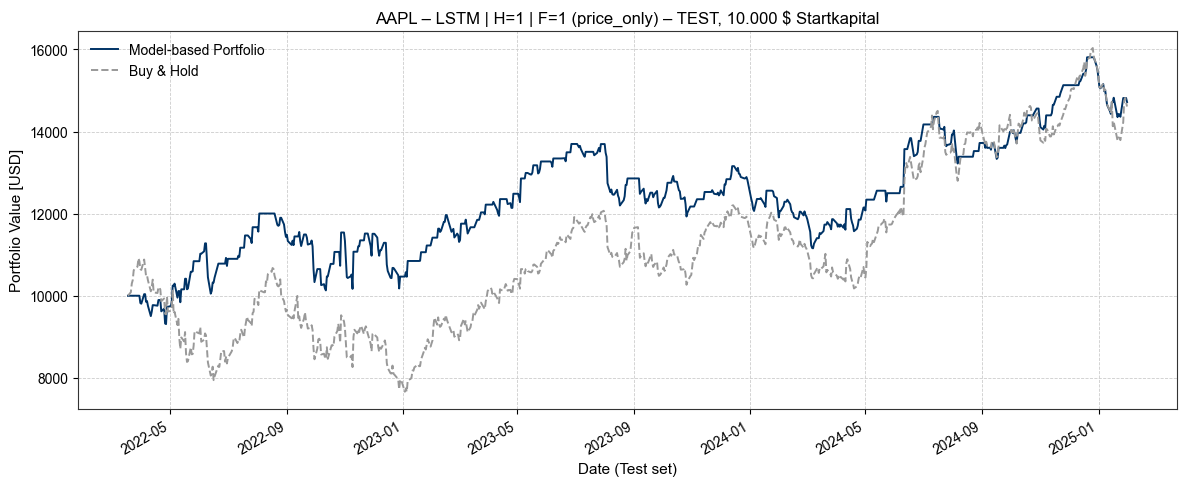


[INFO] Processing Study: LSTM_H3_F1
[WARN] Local best model not found: data\best_models\AAPL\LSTM_H3_F1_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\LSTM_optuna_H3_F1\LSTM_H3_20251204-025834_b128_un128_lay4_e100.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=128 | horizon=3
  LSTM layers=4
  Trainable params: 463,747
[Model] Loaded weights from: ..\data\optuna_checkpoints\LSTM_optuna_H3_F1\LSTM_H3_20251204-025834_b128_un128_lay4_e100.pt
  -> TEST (LEVEL) RMSE=4.166443, R²=0.9824
  -> Final Portfolio = 14,238.70 USD | Buy&Hold = 14,817.13 USD


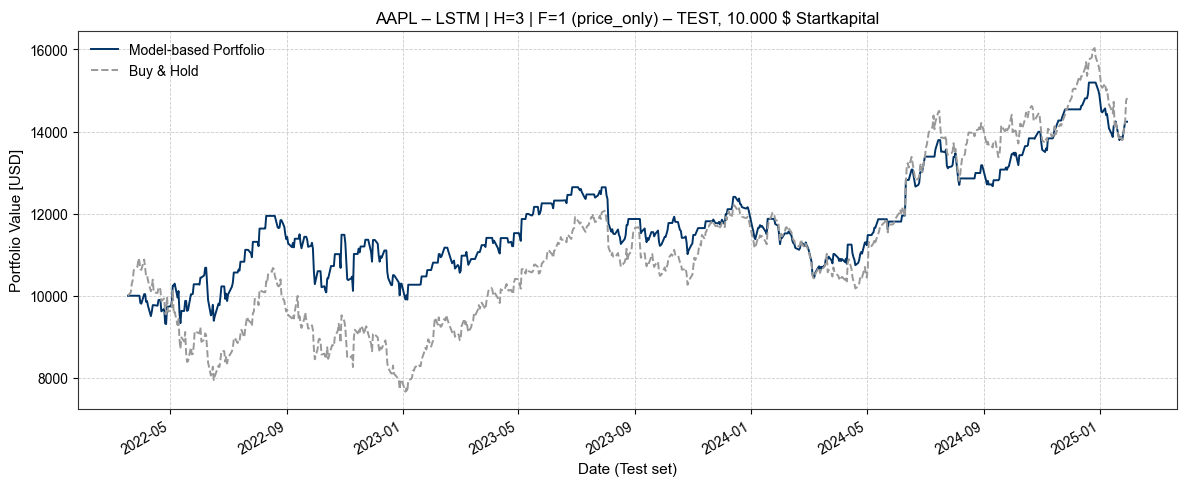


[INFO] Processing Study: LSTM_H5_F1
[WARN] Local best model not found: data\best_models\AAPL\LSTM_H5_F1_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\LSTM_optuna_H5_F1\LSTM_H5_20251204-041739_b128_un64_lay1_e100.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=5
  LSTM layers=1
  Trainable params: 17,477
[Model] Loaded weights from: ..\data\optuna_checkpoints\LSTM_optuna_H5_F1\LSTM_H5_20251204-041739_b128_un64_lay1_e100.pt
  -> TEST (LEVEL) RMSE=5.089947, R²=0.9736
  -> Final Portfolio = 15,933.65 USD | Buy&Hold = 14,229.05 USD


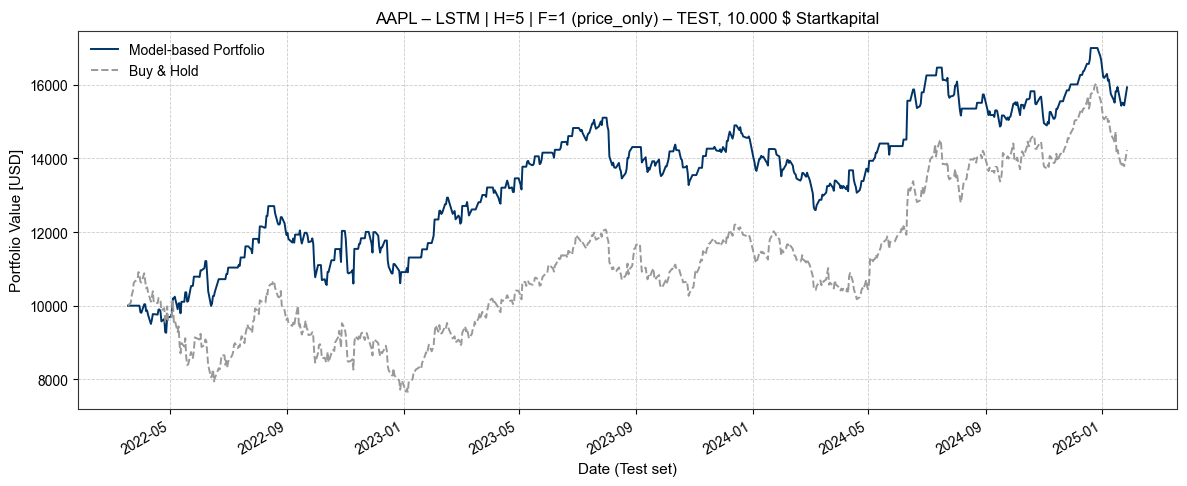


[INFO] Processing Study: LSTM_H10_F1
[WARN] Local best model not found: data\best_models\AAPL\LSTM_H10_F1_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\LSTM_optuna_H10_F1\LSTM_H10_20251204-054744_b128_un128_lay1_e100.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=128 | horizon=10
  LSTM layers=1
  Trainable params: 68,362
[Model] Loaded weights from: ..\data\optuna_checkpoints\LSTM_optuna_H10_F1\LSTM_H10_20251204-054744_b128_un128_lay1_e100.pt
  -> TEST (LEVEL) RMSE=6.974540, R²=0.9504
  -> Final Portfolio = 13,916.04 USD | Buy&Hold = 14,236.48 USD


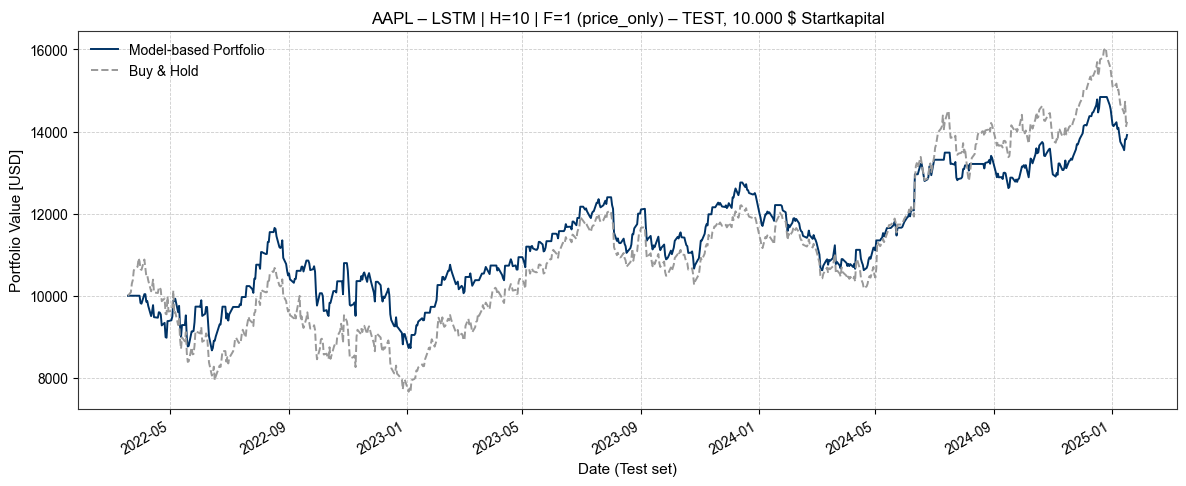


[INFO] Processing Study: LSTM_H15_F1
[WARN] Local best model not found: data\best_models\AAPL\LSTM_H15_F1_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\LSTM_optuna_H15_F1\LSTM_H15_20251204-074857_b128_un64_lay4_e100.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=15
  LSTM layers=4
  Trainable params: 117,967
[Model] Loaded weights from: ..\data\optuna_checkpoints\LSTM_optuna_H15_F1\LSTM_H15_20251204-074857_b128_un64_lay4_e100.pt
  -> TEST (LEVEL) RMSE=8.697346, R²=0.9226
  -> Final Portfolio = 14,728.84 USD | Buy&Hold = 14,661.76 USD


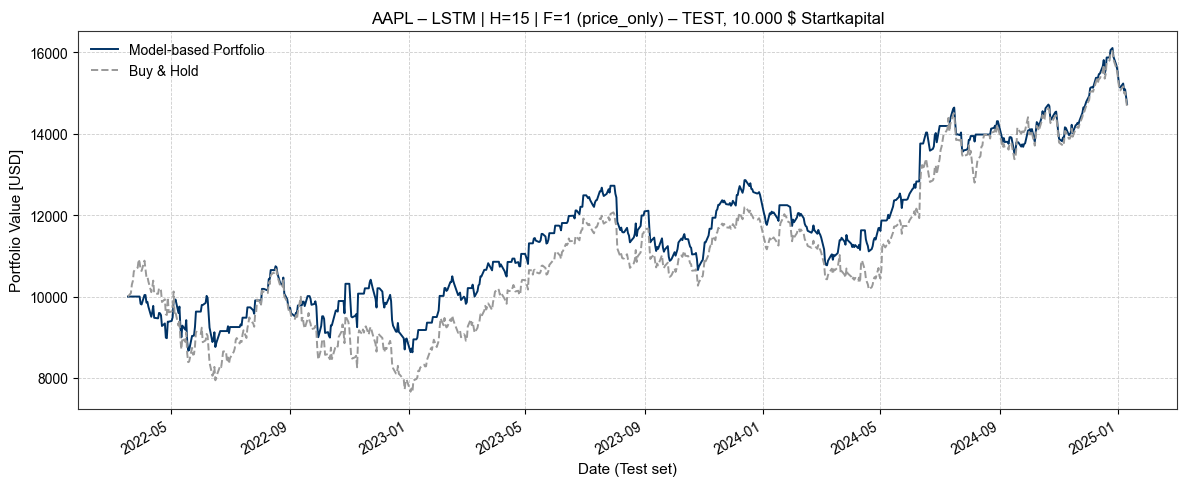


[INFO] Processing Study: LSTM_H1_F5
[WARN] Local best model not found: data\best_models\AAPL\LSTM_H1_F5_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\LSTM_optuna_H1_F5\LSTM_H1_20251204-013929_b128_un64_lay2_e100.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=5 | hidden=64 | horizon=1
  LSTM layers=2
  Trainable params: 51,521
[Model] Loaded weights from: ..\data\optuna_checkpoints\LSTM_optuna_H1_F5\LSTM_H1_20251204-013929_b128_un64_lay2_e100.pt
  -> TEST (LEVEL) RMSE=3.207183, R²=0.9896
  -> Final Portfolio = 12,932.89 USD | Buy&Hold = 14,609.14 USD


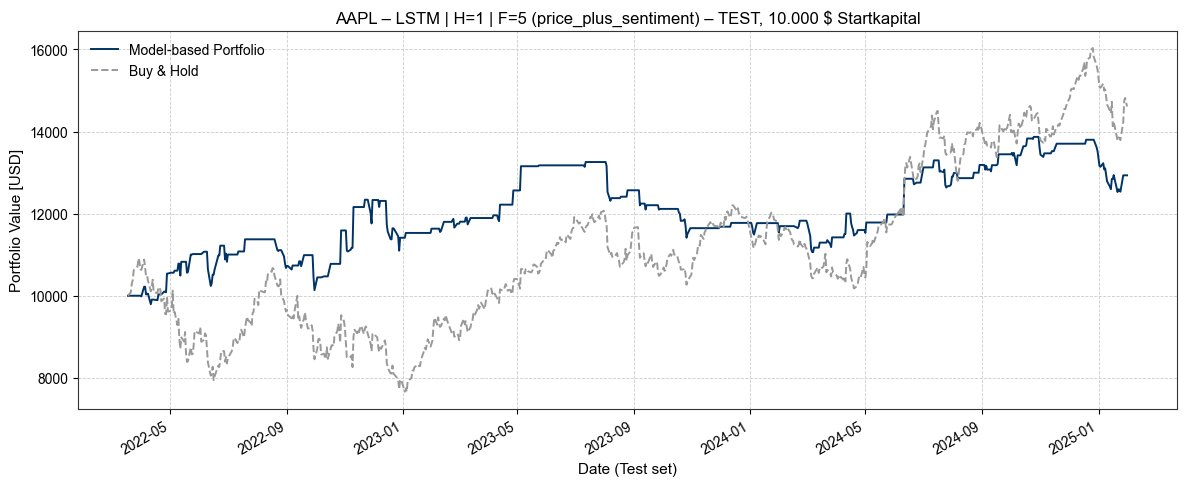


[INFO] Processing Study: LSTM_H3_F5
[WARN] Local best model not found: data\best_models\AAPL\LSTM_H3_F5_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\LSTM_optuna_H3_F5\LSTM_H3_20251204-034812_b128_un128_lay3_e100.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=5 | hidden=128 | horizon=3
  LSTM layers=3
  Trainable params: 333,699
[Model] Loaded weights from: ..\data\optuna_checkpoints\LSTM_optuna_H3_F5\LSTM_H3_20251204-034812_b128_un128_lay3_e100.pt
  -> TEST (LEVEL) RMSE=4.351860, R²=0.9808
  -> Final Portfolio = 13,097.48 USD | Buy&Hold = 14,817.13 USD


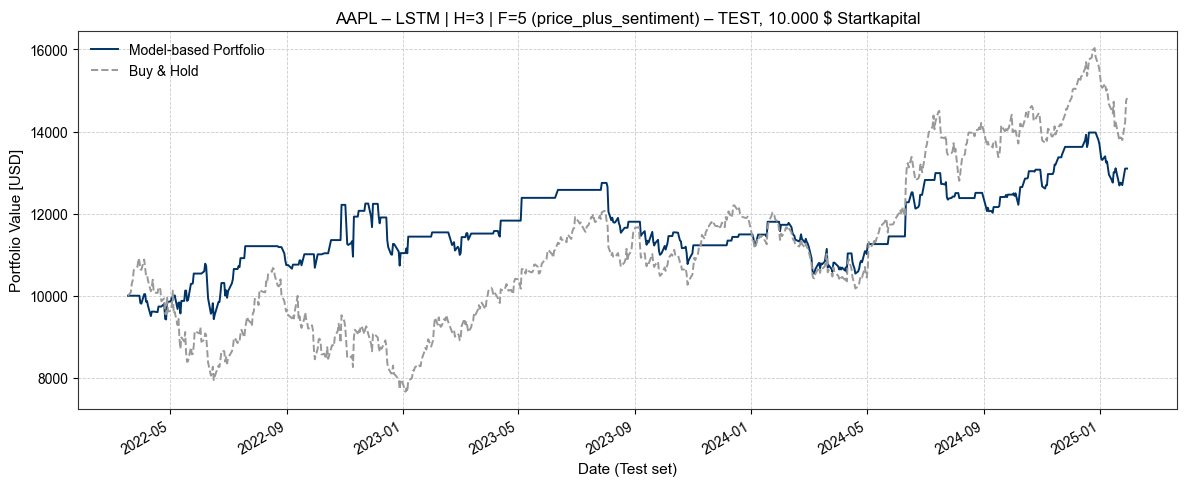


[INFO] Processing Study: LSTM_H5_F5
[WARN] Local best model not found: data\best_models\AAPL\LSTM_H5_F5_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\LSTM_optuna_H5_F5\LSTM_H5_20251204-053355_b128_un32_lay1_e100.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=5 | hidden=32 | horizon=5
  LSTM layers=1
  Trainable params: 5,157
[Model] Loaded weights from: ..\data\optuna_checkpoints\LSTM_optuna_H5_F5\LSTM_H5_20251204-053355_b128_un32_lay1_e100.pt
  -> TEST (LEVEL) RMSE=5.267953, R²=0.9718
  -> Final Portfolio = 14,559.02 USD | Buy&Hold = 14,229.05 USD


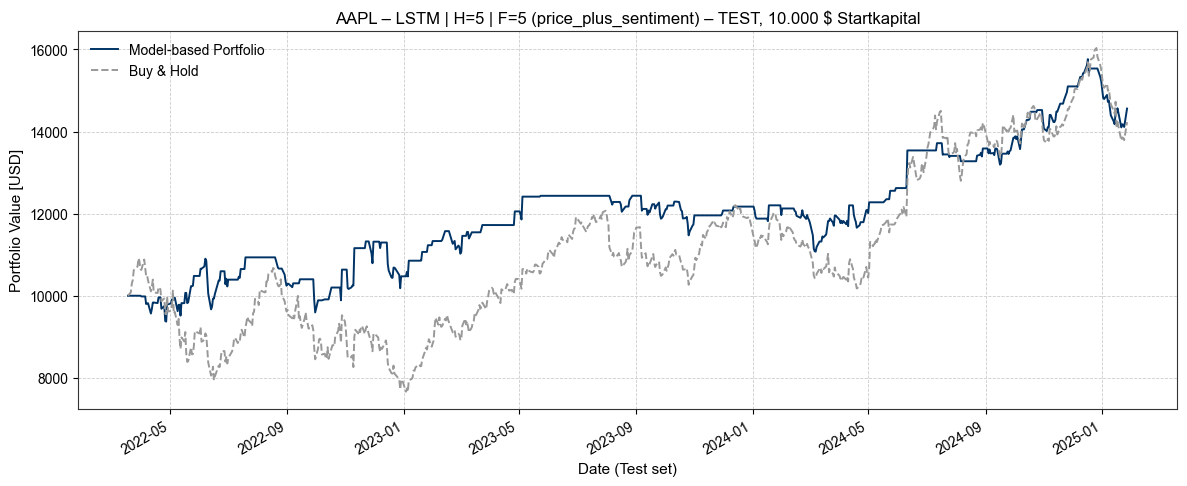


[INFO] Processing Study: LSTM_H10_F5
[WARN] Local best model not found: data\best_models\AAPL\LSTM_H10_F5_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\LSTM_optuna_H10_F5\LSTM_H10_20251204-064317_b128_un64_lay4_e100.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=5 | hidden=64 | horizon=10
  LSTM layers=4
  Trainable params: 118,666
[Model] Loaded weights from: ..\data\optuna_checkpoints\LSTM_optuna_H10_F5\LSTM_H10_20251204-064317_b128_un64_lay4_e100.pt
  -> TEST (LEVEL) RMSE=8.553414, R²=0.9254
  -> Final Portfolio = 11,455.11 USD | Buy&Hold = 14,236.48 USD


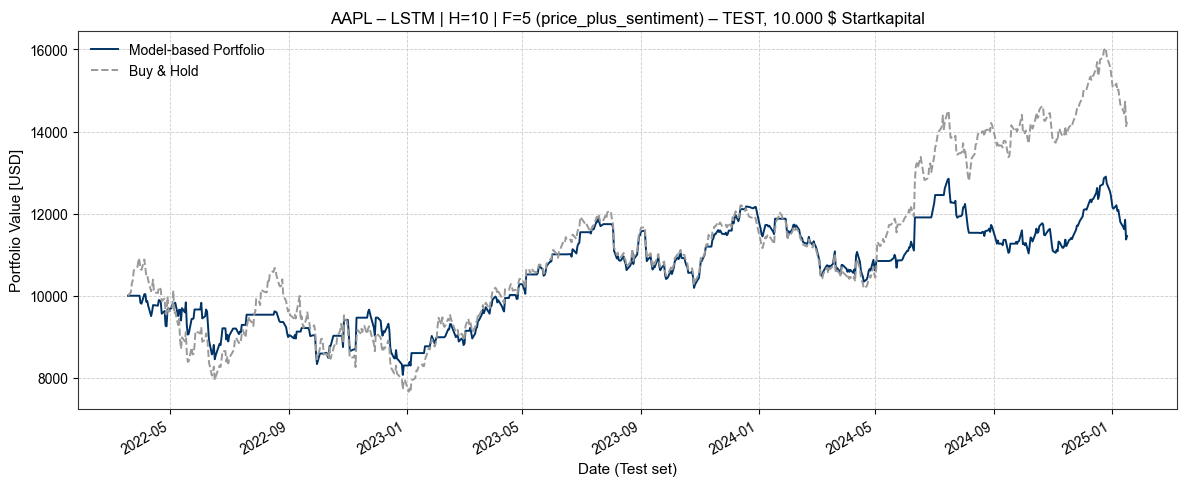


[INFO] Processing Study: LSTM_H15_F5
[WARN] Local best model not found: data\best_models\AAPL\LSTM_H15_F5_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\LSTM_optuna_H15_F5\LSTM_H15_20251204-083500_b128_un128_lay4_e100.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=5 | hidden=128 | horizon=15
  LSTM layers=4
  Trainable params: 467,343
[Model] Loaded weights from: ..\data\optuna_checkpoints\LSTM_optuna_H15_F5\LSTM_H15_20251204-083500_b128_un128_lay4_e100.pt
  -> TEST (LEVEL) RMSE=11.613268, R²=0.8621
  -> Final Portfolio = 13,122.53 USD | Buy&Hold = 14,661.76 USD


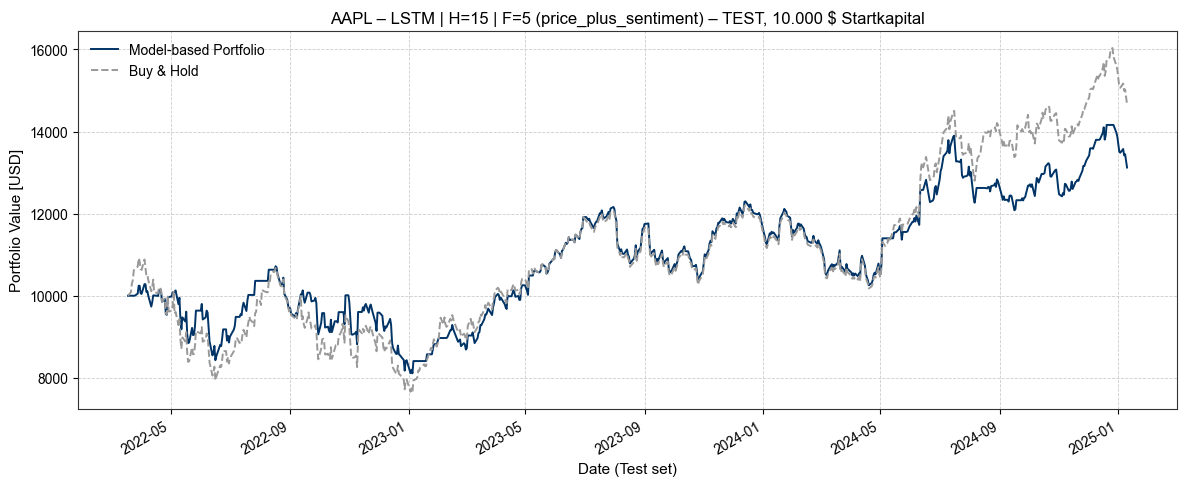


[INFO] Processing Study: xLSTM_H1_F1
[WARN] Local best model not found: data\best_models\AAPL\xLSTM_H1_F1_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\xLSTM_optuna_H1\xLSTM_H1_20251128-232855_b128_un64_layx_e100.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=1
  xLSTM blocks=2, sLSTM at=[1]
  Trainable params: 55,811
[Model] Loaded weights from: ..\data\optuna_checkpoints\xLSTM_optuna_H1\xLSTM_H1_20251128-232855_b128_un64_layx_e100.pt
  -> TEST (LEVEL) RMSE=2.924930, R²=0.9913
  -> Final Portfolio = 14,179.88 USD | Buy&Hold = 14,609.14 USD


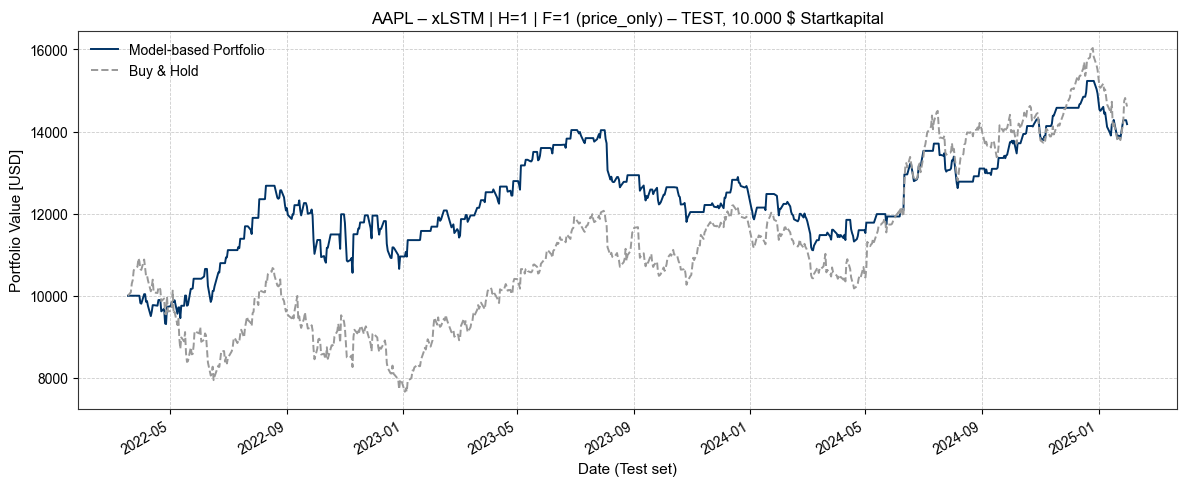


[INFO] Processing Study: xLSTM_H3_F1
[WARN] Local best model not found: data\best_models\AAPL\xLSTM_H3_F1_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\xLSTM_optuna_H3_F1\xLSTM_H3_20251129-123006_b128_un128_layx_e100.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=1 | hidden=128 | horizon=3
  xLSTM blocks=6, sLSTM at=[]
  Trainable params: 346,467
[Model] Loaded weights from: ..\data\optuna_checkpoints\xLSTM_optuna_H3_F1\xLSTM_H3_20251129-123006_b128_un128_layx_e100.pt
  -> TEST (LEVEL) RMSE=4.137181, R²=0.9826
  -> Final Portfolio = 13,670.22 USD | Buy&Hold = 14,817.13 USD


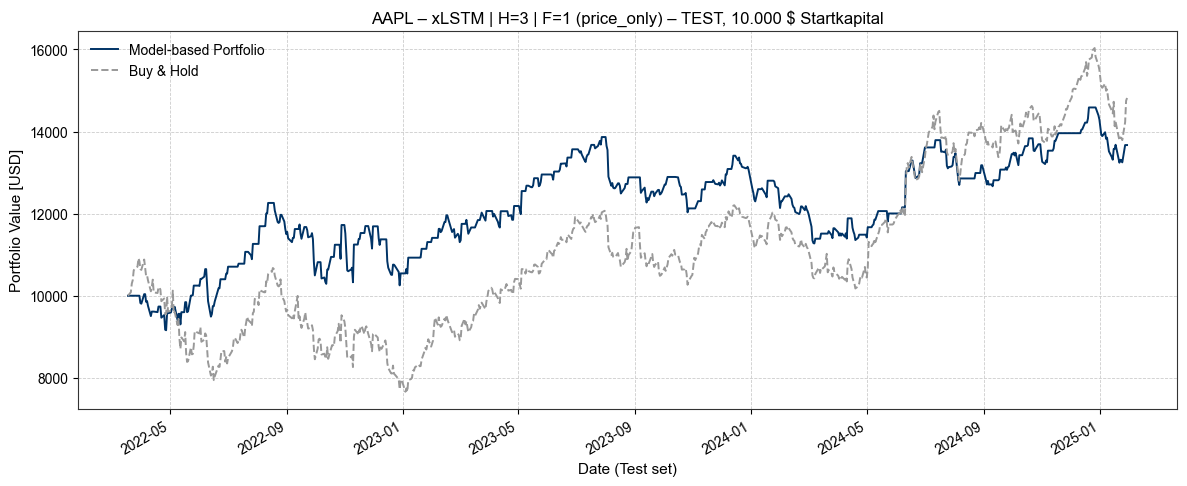


[INFO] Processing Study: xLSTM_H5_F1
[WARN] Local best model not found: data\best_models\AAPL\xLSTM_H5_F1_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\xLSTM_H5_F1\xLSTM_H5_20251201-141137_b128_un96_layx_e100.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=1 | hidden=96 | horizon=5
  xLSTM blocks=4, sLSTM at=[]
  Trainable params: 241,165
[Model] Loaded weights from: ..\data\optuna_checkpoints\xLSTM_H5_F1\xLSTM_H5_20251201-141137_b128_un96_layx_e100.pt
  -> TEST (LEVEL) RMSE=5.176548, R²=0.9727
  -> Final Portfolio = 15,289.19 USD | Buy&Hold = 14,229.05 USD


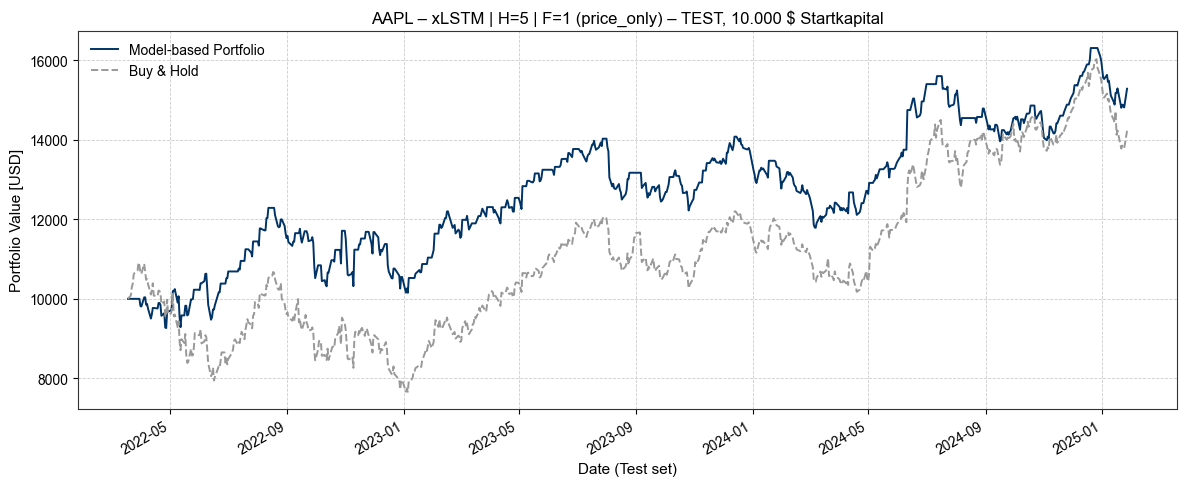


[INFO] Processing Study: xLSTM_H10_F1
[WARN] Local best model not found: data\best_models\AAPL\xLSTM_H10_F1_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\xLSTM_H10_F1\xLSTM_H10_20251202-054243_b128_un128_layx_e100.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=1 | hidden=128 | horizon=10
  xLSTM blocks=8, sLSTM at=[]
  Trainable params: 427,690
[Model] Loaded weights from: ..\data\optuna_checkpoints\xLSTM_H10_F1\xLSTM_H10_20251202-054243_b128_un128_layx_e100.pt
  -> TEST (LEVEL) RMSE=7.156259, R²=0.9477
  -> Final Portfolio = 14,292.26 USD | Buy&Hold = 14,236.48 USD


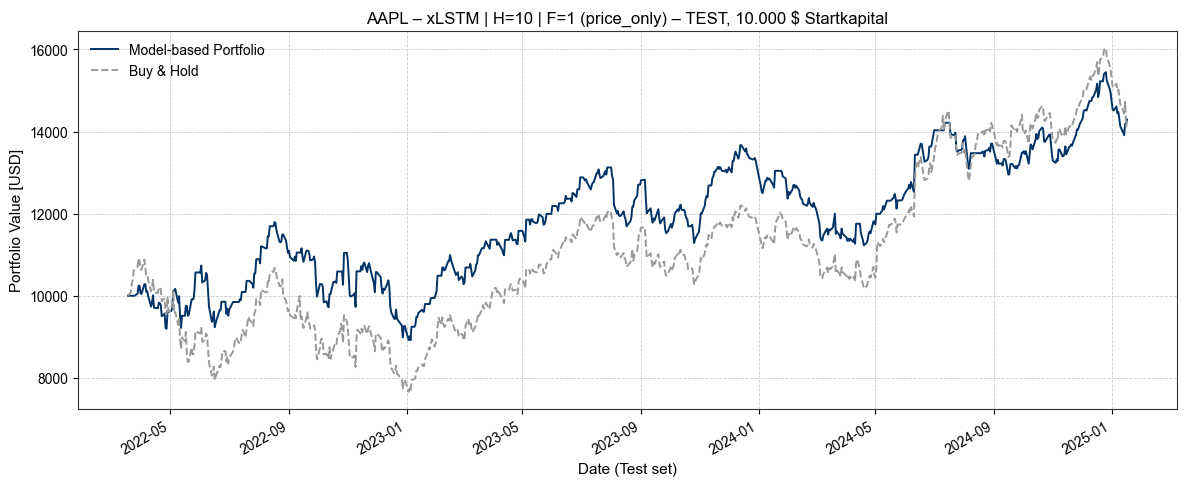


[INFO] Processing Study: xLSTM_H15_F1
[WARN] Local best model not found: data\best_models\AAPL\xLSTM_H15_F1_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\xLSTM_H15_F1\xLSTM_H15_20251203-040321_b128_un64_layx_e100.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=15
  xLSTM blocks=8, sLSTM at=[7]
  Trainable params: 175,871
[Model] Loaded weights from: ..\data\optuna_checkpoints\xLSTM_H15_F1\xLSTM_H15_20251203-040321_b128_un64_layx_e100.pt
  -> TEST (LEVEL) RMSE=8.807541, R²=0.9207
  -> Final Portfolio = 14,051.73 USD | Buy&Hold = 14,661.76 USD


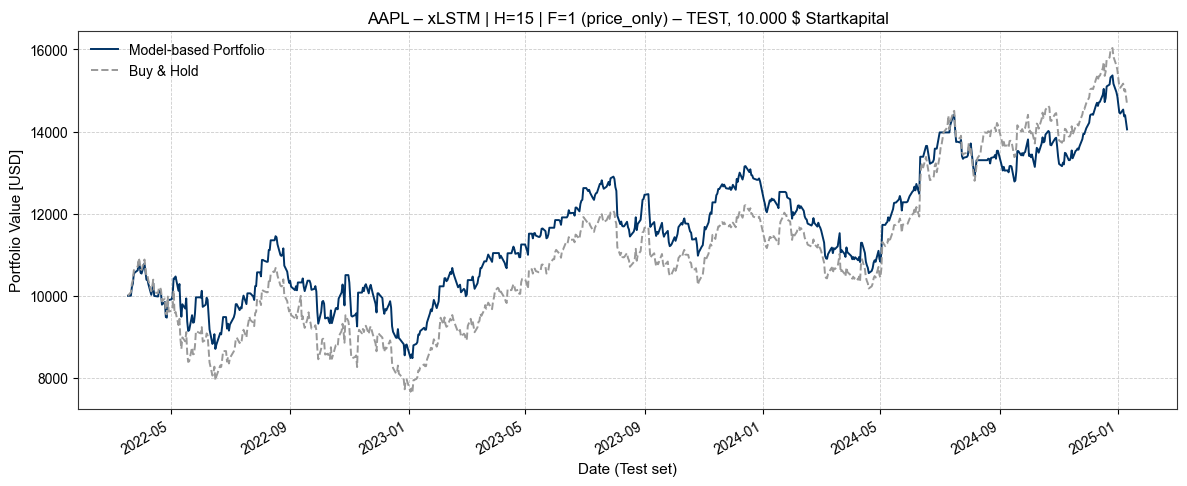


[INFO] Processing Study: xLSTM_H1_F5
[WARN] Local best model not found: data\best_models\AAPL\xLSTM_H1_F5_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\xLSTM_optuna_H1\xLSTM_H1_20251128-080104_b128_un96_layx_e100.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=5 | hidden=96 | horizon=1
  xLSTM blocks=6, sLSTM at=[]
  Trainable params: 372,889
[Model] Loaded weights from: ..\data\optuna_checkpoints\xLSTM_optuna_H1\xLSTM_H1_20251128-080104_b128_un96_layx_e100.pt
  -> TEST (LEVEL) RMSE=6.480765, R²=0.9575
  -> Final Portfolio = 12,076.00 USD | Buy&Hold = 14,609.14 USD


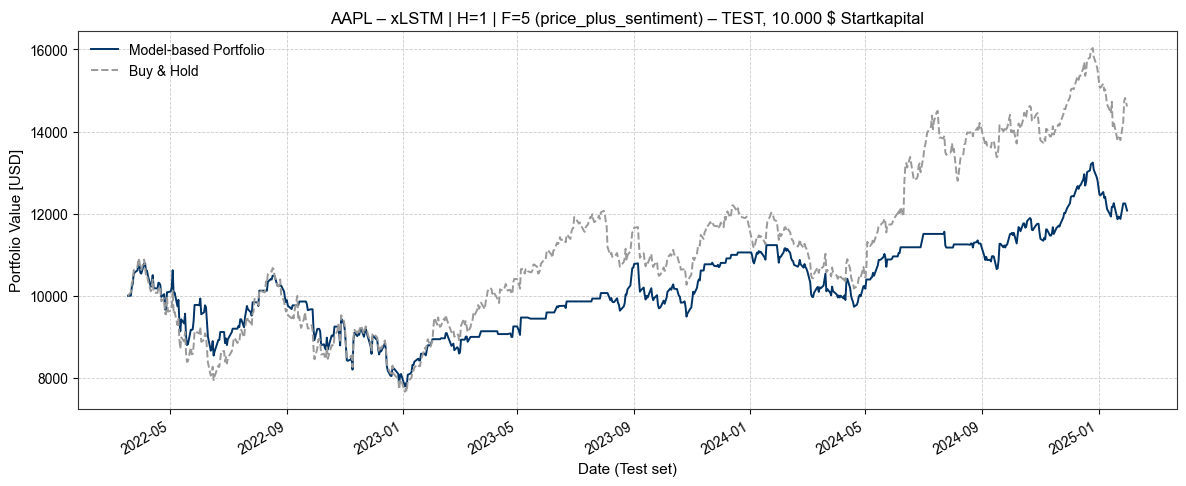


[INFO] Processing Study: xLSTM_H3_F5
[WARN] Local best model not found: data\best_models\AAPL\xLSTM_H3_F5_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\xLSTM_optuna_H3_F5\xLSTM_H3_20251129-055701_b128_un32_layx_e100.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=5 | hidden=32 | horizon=3
  xLSTM blocks=2, sLSTM at=[]
  Trainable params: 16,583
[Model] Loaded weights from: ..\data\optuna_checkpoints\xLSTM_optuna_H3_F5\xLSTM_H3_20251129-055701_b128_un32_layx_e100.pt
  -> TEST (LEVEL) RMSE=5.058478, R²=0.9740
  -> Final Portfolio = 14,155.97 USD | Buy&Hold = 14,817.13 USD


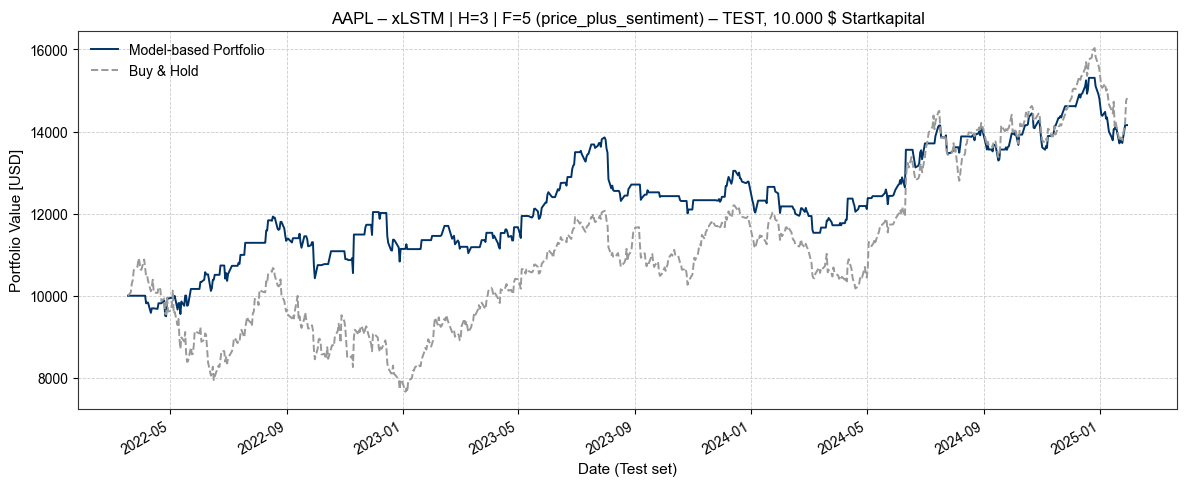


[INFO] Processing Study: xLSTM_H5_F5
[WARN] Local best model not found: data\best_models\AAPL\xLSTM_H5_F5_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\xLSTM_optuna_H5_F5\xLSTM_H5_20251130-080721_b128_un96_layx_e100.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=5 | hidden=96 | horizon=5
  xLSTM blocks=6, sLSTM at=[]
  Trainable params: 245,777
[Model] Loaded weights from: ..\data\optuna_checkpoints\xLSTM_optuna_H5_F5\xLSTM_H5_20251130-080721_b128_un96_layx_e100.pt
  -> TEST (LEVEL) RMSE=7.416477, R²=0.9440
  -> Final Portfolio = 12,297.15 USD | Buy&Hold = 14,229.05 USD


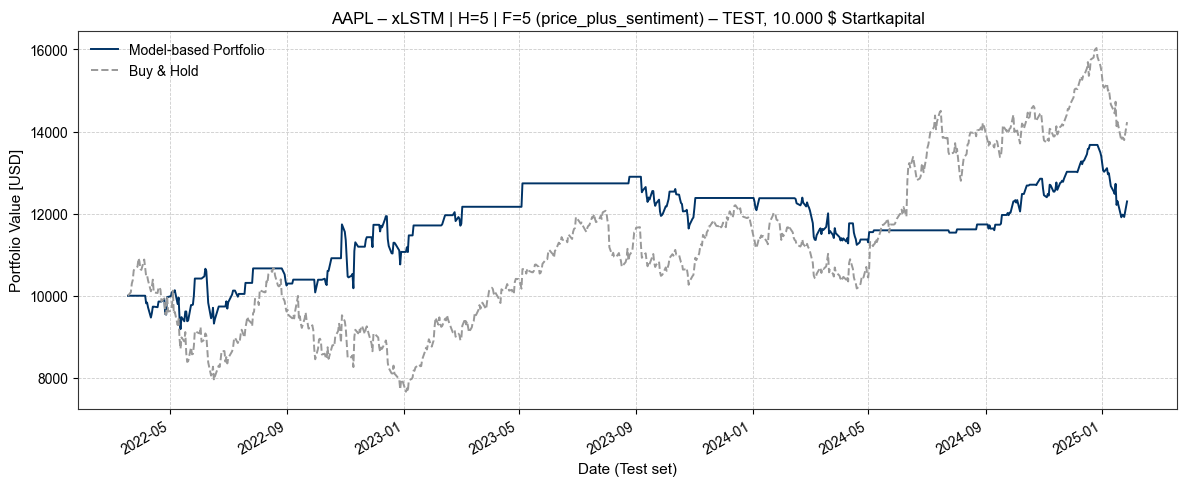


[INFO] Processing Study: xLSTM_H10_F5
[WARN] Local best model not found: data\best_models\AAPL\xLSTM_H10_F5_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\xLSTM_optuna_H10_F5\xLSTM_H10_20251130-141436_b128_un64_layx_e100.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=5 | hidden=64 | horizon=10
  xLSTM blocks=8, sLSTM at=[]
  Trainable params: 245,898
[Model] Loaded weights from: ..\data\optuna_checkpoints\xLSTM_optuna_H10_F5\xLSTM_H10_20251130-141436_b128_un64_layx_e100.pt
  -> TEST (LEVEL) RMSE=7.751826, R²=0.9387
  -> Final Portfolio = 13,818.46 USD | Buy&Hold = 14,236.48 USD


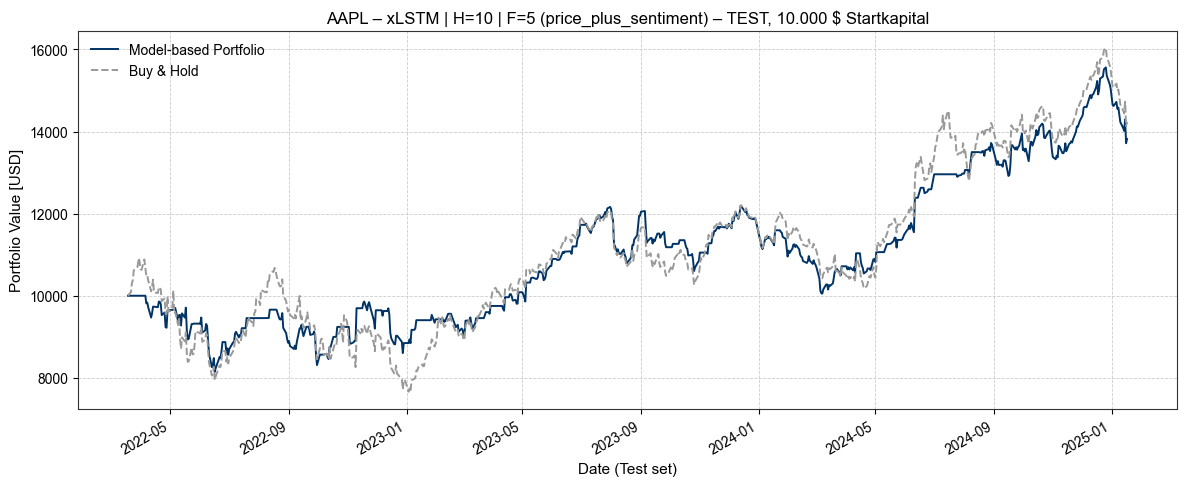


[INFO] Processing Study: xLSTM_H15_F5
[WARN] Local best model not found: data\best_models\AAPL\xLSTM_H15_F5_AAPL.pt, fallback to original checkpoint.
  -> Using checkpoint: ..\data\optuna_checkpoints\xLSTM_optuna_H15_F5\xLSTM_H15_20251201-034146_b128_un64_layx_e100.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=5 | hidden=64 | horizon=15
  xLSTM blocks=6, sLSTM at=[5]
  Trainable params: 180,535
[Model] Loaded weights from: ..\data\optuna_checkpoints\xLSTM_optuna_H15_F5\xLSTM_H15_20251201-034146_b128_un64_layx_e100.pt
  -> TEST (LEVEL) RMSE=9.932954, R²=0.8991
  -> Final Portfolio = 13,059.40 USD | Buy&Hold = 14,661.76 USD


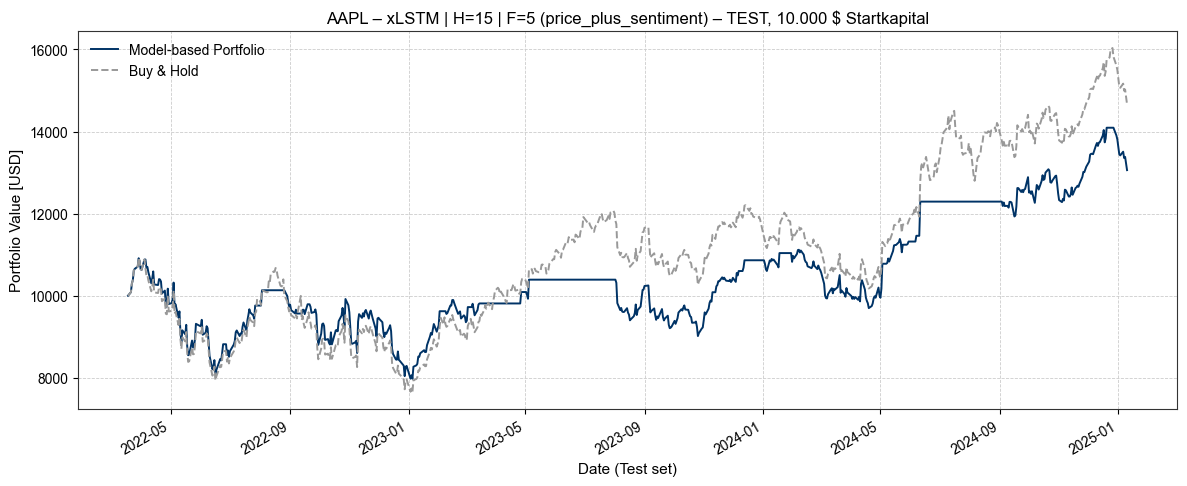

In [7]:
# =========================
# Hauptschleife:
# Alle 20 Modelle auswerten, Portfolios simulieren
# =========================

results: List[Dict[str, Any]] = []

for model_type in sorted(MODEL_TYPES):
    for feature_set_name, feature_cols in FEATURE_SETS.items():
        n_features = len(feature_cols)

        for horizon in sorted(HORIZONS):
            study_name = f"{model_type}_H{horizon}_F{n_features}"
            print(f"\n[INFO] Processing Study: {study_name}")

            # --- Optuna-Study laden ---
            try:
                study = optuna.load_study(
                    study_name=study_name,
                    storage=STORAGE_URL,
                )
            except Exception as e:
                print(f"[WARN] Could not load study '{study_name}': {e}")
                continue

            # --- besten Trial bestimmen ---
            try:
                best_trial = select_best_trial(study)
            except Exception as e:
                print(f"[WARN] Could not select best trial for '{study_name}': {e}")
                continue

            # Konfiguration & Original-Checkpoint (falls BestModels nicht existieren)
            best_config = best_trial.user_attrs.get("config", None)
            orig_ckpt = best_trial.user_attrs.get("best_checkpoint_path", None)

            if best_config is None or orig_ckpt is None:
                print(f"[WARN] Missing config or checkpoint in '{study_name}'.")
                continue

            # Zielpfad in data/best_models/AAPL
            local_ckpt = BESTMODELS_DIR / f"{model_type}_H{horizon}_F{n_features}_{TICKER}.pt"

            if local_ckpt.is_file():
                ckpt_to_use = local_ckpt
            else:
                print(f"[WARN] Local best model not found: {local_ckpt}, fallback to original checkpoint.")
                ckpt_to_use = Path(orig_ckpt)
                if not ckpt_to_use.is_file():
                    print(f"[WARN] Original checkpoint also not found: {ckpt_to_use}")
                    continue

            print(f"  -> Using checkpoint: {ckpt_to_use}")

            # --- Testdaten vorbereiten ---
            data_dict = prepare_test_data_for_config(
                feature_cols=feature_cols,
                horizon=horizon,
            )

            prep = data_dict["prep"]
            X_te = data_dict["X_te"]
            y_te = data_dict["y_te"]
            dates_te = data_dict["dates_te"]
            baseT_te = data_dict["baseT_te"]

            # --- Modell aufbauen und Checkpoint laden ---
            eval_model = Model()
            eval_model.build(config=best_config, model_type=model_type)
            eval_model.load(str(ckpt_to_use))

            # --- Vorhersagen auf TEST-Daten (skaliert) ---
            y_test_scaled = y_te  # [N, H, 1]
            y_pred_scaled = eval_model.predict_multi_horizon(
                X_te,
                batch_size=BATCH_SIZE,
                verbose=0,
            )  # [N, H]

            # --- Denormalisieren & Test-Metriken ---
            metrics_dict = denormalise_test_and_metrics(
                prep=prep,
                y_test_scaled=y_test_scaled,
                y_pred_scaled=y_pred_scaled,
                baseT_te=baseT_te,
            )

            y_true_level = metrics_dict["y_true_level"]  # [N, H]
            y_pred_level = metrics_dict["y_pred_level"]  # [N, H]
            test_rmse_level = metrics_dict["test_rmse_level"]
            test_r2_level = metrics_dict["test_r2_level"]

            print(
                f"  -> TEST (LEVEL) RMSE={test_rmse_level:.6f}, R²={test_r2_level:.4f}"
            )

            # --- Multi-Horizont-Signal ER_t & Downside DD_t ---
            er_dd = compute_er_and_dd(
                y_pred_level=y_pred_level,
                y_true_level=y_true_level,
                horizon=horizon,
            )

            ER = er_dd["ER"]                    # [N]
            DD = er_dd["DD"]                    # [N]
            base_price_series = er_dd["base_price"]  # [N]
            decision_dates = dates_te[:, 0]     # [N] – erster Horizont-Tag als Entscheidungsdatum

            # --- Portfolio-Simulation (Long/Flat) ---
            sim = simulate_portfolio_long_flat(
                dates=decision_dates,
                prices=base_price_series,
                ER=ER,
                DD=DD,
                initial_capital=INITIAL_CAPITAL,
                buy_threshold=BUY_THRESHOLD,
                sell_threshold=SELL_THRESHOLD,
                dd_min=DD_MIN,
            )

            portfolio_values = sim["portfolio_values"]
            bh_values = sim["bh_values"]
            final_portfolio_value = sim["final_portfolio_value"]
            final_bh_value = sim["final_bh_value"]

            print(
                f"  -> Final Portfolio = {final_portfolio_value:,.2f} USD | "
                f"Buy&Hold = {final_bh_value:,.2f} USD"
            )

            # --- Plot: Portfolio vs. Buy&Hold ---
            plot_portfolio_vs_bh(
                dates=decision_dates,
                portfolio_values=portfolio_values,
                bh_values=bh_values,
                model_type=model_type,
                horizon=horizon,
                n_features=n_features,
                feature_set_name=feature_set_name,
            )

            # --- Ergebnisse für Vergleichstabelle sammeln ---
            results.append(
                {
                    "asset": asset_name,
                    "model_type": model_type,
                    "feature_set": feature_set_name,
                    "n_features": n_features,
                    "horizon": horizon,
                    "test_rmse_level": test_rmse_level,
                    "test_r2_level": test_r2_level,
                    "final_portfolio_value": final_portfolio_value,
                    "final_bh_value": final_bh_value,
                    "excess_return_pct": (final_portfolio_value / final_bh_value - 1.0)
                    if final_bh_value != 0
                    else np.nan,
                    "checkpoint_used": str(ckpt_to_use),
                    "study_name": study_name,
                }
            )

In [8]:
# =========================
# Vergleichstabelle & Übersichtsplot
# =========================

if len(results) == 0:
    print("[WARN] No results collected. Please check studies and best model files.")
else:
    df_results = pd.DataFrame(results)

    df_results = df_results.sort_values(
        by=["model_type", "n_features", "horizon"],
        ascending=[True, True, True],
    ).reset_index(drop=True)

    display_cols = [
        "asset",
        "model_type",
        "feature_set",
        "n_features",
        "horizon",
        "test_rmse_level",
        "test_r2_level",
        "final_portfolio_value",
        "final_bh_value",
        "excess_return_pct",
    ]

    df_display = df_results[display_cols].copy()
    df_display["test_rmse_level"] = df_display["test_rmse_level"].round(4)
    df_display["test_r2_level"] = df_display["test_r2_level"].round(4)
    df_display["final_portfolio_value"] = df_display["final_portfolio_value"].round(2)
    df_display["final_bh_value"] = df_display["final_bh_value"].round(2)
    df_display["excess_return_pct"] = (df_display["excess_return_pct"] * 100).round(2)

    print("\n============================================")
    print("Portfolio-Performance (Long/Flat) vs. Buy&Hold")
    print("Basis: TEST-Predictions, denormalisierte Preise")
    print("============================================\n")

    display(df_display)



Portfolio-Performance (Long/Flat) vs. Buy&Hold
Basis: TEST-Predictions, denormalisierte Preise



,asset,model_type,feature_set,n_features,horizon,test_rmse_level,test_r2_level,final_portfolio_value,final_bh_value,excess_return_pct
0,AAPL,LSTM,price_only,1,1,2.9437,0.9912,14716.54,14609.14,0.74
1,AAPL,LSTM,price_only,1,3,4.1664,0.9824,14238.70,14817.13,-3.90
2,AAPL,LSTM,price_only,1,5,5.0899,0.9736,15933.65,14229.05,11.98
3,AAPL,LSTM,price_only,1,10,6.9745,0.9504,13916.04,14236.48,-2.25
4,AAPL,LSTM,price_only,1,15,8.6973,0.9226,14728.84,14661.76,0.46
5,AAPL,LSTM,price_plus_sentiment,5,1,3.2072,0.9896,12932.89,14609.14,-11.47
6,AAPL,LSTM,price_plus_sentiment,5,3,4.3519,0.9808,13097.48,14817.13,-11.61
7,AAPL,LSTM,price_plus_sentiment,5,5,5.2680,0.9718,14559.02,14229.05,2.32
8,AAPL,LSTM,price_plus_sentiment,5,10,8.5534,0.9254,11455.11,14236.48,-19.54
9,AAPL,LSTM,price_plus_sentiment,5,15,11.6133,0.8621,13122.53,14661.76,-10.50



Portfolio-Performance (Long/Flat) vs. Buy&Hold
Basis: TEST-Predictions, denormalisierte Preise



,asset,model_type,feature_set,n_features,horizon,test_rmse_level,test_r2_level,final_portfolio_value,final_bh_value,excess_return_pct
0,AAPL,LSTM,price_only,1,1,2.9437,0.9912,14716.54,14609.14,0.74
1,AAPL,LSTM,price_only,1,3,4.1664,0.9824,14238.70,14817.13,-3.90
2,AAPL,LSTM,price_only,1,5,5.0899,0.9736,15933.65,14229.05,11.98
3,AAPL,LSTM,price_only,1,10,6.9745,0.9504,13916.04,14236.48,-2.25
4,AAPL,LSTM,price_only,1,15,8.6973,0.9226,14728.84,14661.76,0.46
5,AAPL,LSTM,price_plus_sentiment,5,1,3.2072,0.9896,12932.89,14609.14,-11.47
6,AAPL,LSTM,price_plus_sentiment,5,3,4.3519,0.9808,13097.48,14817.13,-11.61
7,AAPL,LSTM,price_plus_sentiment,5,5,5.2680,0.9718,14559.02,14229.05,2.32
8,AAPL,LSTM,price_plus_sentiment,5,10,8.5534,0.9254,11455.11,14236.48,-19.54
9,AAPL,LSTM,price_plus_sentiment,5,15,11.6133,0.8621,13122.53,14661.76,-10.50


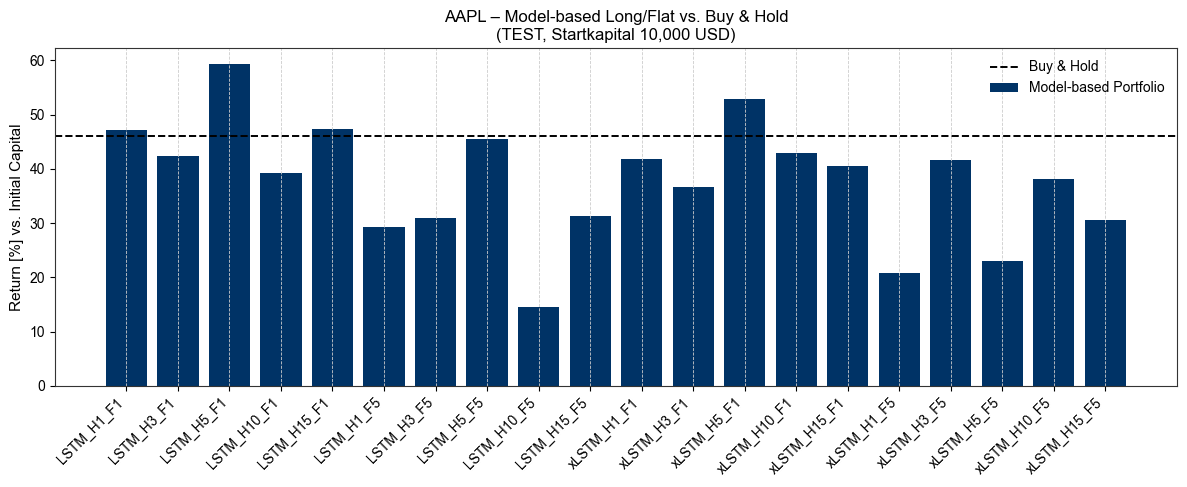

In [9]:
# =========================
# Vergleichstabelle & Übersichtsplot
# =========================

if len(results) == 0:
    print("[WARN] No results collected. Please check studies and best model files.")
else:
    df_results = pd.DataFrame(results)

    df_results = df_results.sort_values(
        by=["model_type", "n_features", "horizon"],
        ascending=[True, True, True],
    ).reset_index(drop=True)

    display_cols = [
        "asset",
        "model_type",
        "feature_set",
        "n_features",
        "horizon",
        "test_rmse_level",
        "test_r2_level",
        "final_portfolio_value",
        "final_bh_value",
        "excess_return_pct",
    ]

    df_display = df_results[display_cols].copy()
    df_display["test_rmse_level"] = df_display["test_rmse_level"].round(4)
    df_display["test_r2_level"] = df_display["test_r2_level"].round(4)
    df_display["final_portfolio_value"] = df_display["final_portfolio_value"].round(2)
    df_display["final_bh_value"] = df_display["final_bh_value"].round(2)
    df_display["excess_return_pct"] = (df_display["excess_return_pct"] * 100).round(2)

    print("\n============================================")
    print("Portfolio-Performance (Long/Flat) vs. Buy&Hold")
    print("Basis: TEST-Predictions, denormalisierte Preise")
    print("============================================\n")

    display(df_display)

    # Barplot: Endwerte relativ zum Startkapital
    plt.figure(figsize=(12, 5))
    x = np.arange(len(df_display))
    model_returns = df_display["final_portfolio_value"] / INITIAL_CAPITAL - 1.0
    bh_returns = df_display["final_bh_value"] / INITIAL_CAPITAL - 1.0

    plt.bar(x, model_returns * 100, label="Model-based Portfolio")
    # Buy&Hold ist bei allen Reihen gleich -> horizontale Linie
    bh_level = bh_returns.iloc[0] * 100
    plt.axhline(bh_level, color="black", linestyle="--", label="Buy & Hold")

    labels = [
        f"{mt}_H{h}_F{f}"
        for mt, h, f in zip(
            df_display["model_type"],
            df_display["horizon"],
            df_display["n_features"],
        )
    ]
    plt.xticks(x, labels, rotation=45, ha="right")

    plt.ylabel("Return [%] vs. Initial Capital")
    plt.title(
        f"{asset_name} – Model-based Long/Flat vs. Buy & Hold\n"
        f"(TEST, Startkapital {INITIAL_CAPITAL:,.0f} USD)"
    )
    plt.grid(axis="y")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [10]:
# -------------------------------------------------
# Export der geplotteten Übersichtsplot-Daten als CSV-Text (für Copy/Paste)
# -------------------------------------------------
if "df_display" not in globals():
    print("[WARN] df_display not found. Bitte erst die Ergebniszellen ausführen.")
else:
    df_plot = df_display.copy()

    # Returns relativ zum Startkapital (wie im Plot)
    df_plot["model_return_pct"] = (df_plot["final_portfolio_value"] / INITIAL_CAPITAL - 1.0) * 100
    df_plot["bh_return_pct"] = (df_plot["final_bh_value"] / INITIAL_CAPITAL - 1.0) * 100

    # Plot-Label wie im Plot
    df_plot["plot_label"] = [
        f"{mt}_H{h}_F{f}"
        for mt, h, f in zip(
            df_plot["model_type"],
            df_plot["horizon"],
            df_plot["n_features"],
        )
    ]

    # Nur die wirklich geplotteten (und sinnvollen) Spalten
    df_plot_out = df_plot[[
        "plot_label",
        "model_type",
        "feature_set",
        "n_features",
        "horizon",
        "final_portfolio_value",
        "final_bh_value",
        "model_return_pct",
        "bh_return_pct",
        "excess_return_pct",
        "test_rmse_level",
        "test_r2_level",
    ]].copy()

    # Rundung für saubere CSV-Ausgabe
    df_plot_out["final_portfolio_value"] = df_plot_out["final_portfolio_value"].round(2)
    df_plot_out["final_bh_value"] = df_plot_out["final_bh_value"].round(2)
    df_plot_out["model_return_pct"] = df_plot_out["model_return_pct"].round(3)
    df_plot_out["bh_return_pct"] = df_plot_out["bh_return_pct"].round(3)
    df_plot_out["excess_return_pct"] = df_plot_out["excess_return_pct"].round(3)
    df_plot_out["test_rmse_level"] = df_plot_out["test_rmse_level"].round(6)
    df_plot_out["test_r2_level"] = df_plot_out["test_r2_level"].round(6)

    # CSV-Text ins Notebook printen
    csv_text = df_plot_out.to_csv(index=False)
    print(csv_text)


plot_label,model_type,feature_set,n_features,horizon,final_portfolio_value,final_bh_value,model_return_pct,bh_return_pct,excess_return_pct,test_rmse_level,test_r2_level
LSTM_H1_F1,LSTM,price_only,1,1,14716.54,14609.14,47.165,46.091,0.74,2.9437,0.9912
LSTM_H3_F1,LSTM,price_only,1,3,14238.7,14817.13,42.387,48.171,-3.9,4.1664,0.9824
LSTM_H5_F1,LSTM,price_only,1,5,15933.65,14229.05,59.336,42.29,11.98,5.0899,0.9736
LSTM_H10_F1,LSTM,price_only,1,10,13916.04,14236.48,39.16,42.365,-2.25,6.9745,0.9504
LSTM_H15_F1,LSTM,price_only,1,15,14728.84,14661.76,47.288,46.618,0.46,8.6973,0.9226
LSTM_H1_F5,LSTM,price_plus_sentiment,5,1,12932.89,14609.14,29.329,46.091,-11.47,3.2072,0.9896
LSTM_H3_F5,LSTM,price_plus_sentiment,5,3,13097.48,14817.13,30.975,48.171,-11.61,4.3519,0.9808
LSTM_H5_F5,LSTM,price_plus_sentiment,5,5,14559.02,14229.05,45.59,42.29,2.32,5.268,0.9718
LSTM_H10_F5,LSTM,price_plus_sentiment,5,10,11455.11,14236.48,14.551,42.365,-19.54,8.5534,0.9254
LSTM_H15_F5,LSTM,price_plus_sentiment,5,15,13